**Imports**

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
%matplotlib inline

**Data Loading and Visualization**

In [39]:
sesmic_path = "/content/drive/MyDrive/Dataset/data/seis2_1_0.npy"
velocity_path = "/content/drive/MyDrive/Dataset/data/vel2_1_0.npy"

In [40]:
x = np.load(sesmic_path)
y = np.load(velocity_path)

In [41]:
print(x.shape)
print(y.shape)
print(x.dtype)
print(y.dtype)

(500, 5, 1000, 70)
(500, 1, 70, 70)
float32
float32


In [42]:
y = y.squeeze(1)
print(y.shape)

(500, 70, 70)


In [43]:
r0 = x[0,0, : ,0]
r1 = x[0,0, : ,1]
r2 = x[0,0, : ,2]
r3 = x[0,0, : ,3]

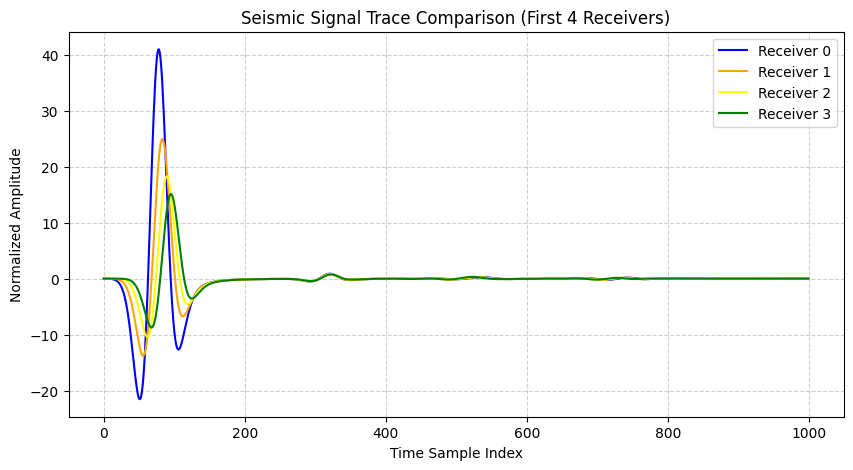

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(r0, color='blue', label='Receiver 0')
plt.plot(r1, color='orange', label='Receiver 1')
plt.plot(r2, color='yellow', label='Receiver 2')
plt.plot(r3, color='green', label='Receiver 3')

plt.title('Seismic Signal Trace Comparison (First 4 Receivers)')
plt.xlabel('Time Sample Index')
plt.ylabel('Normalized Amplitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("seismic_signals_receivers_0-3.png", format="png")
plt.show()

In [45]:
x_sample = x[0]
y_sample = y[0]

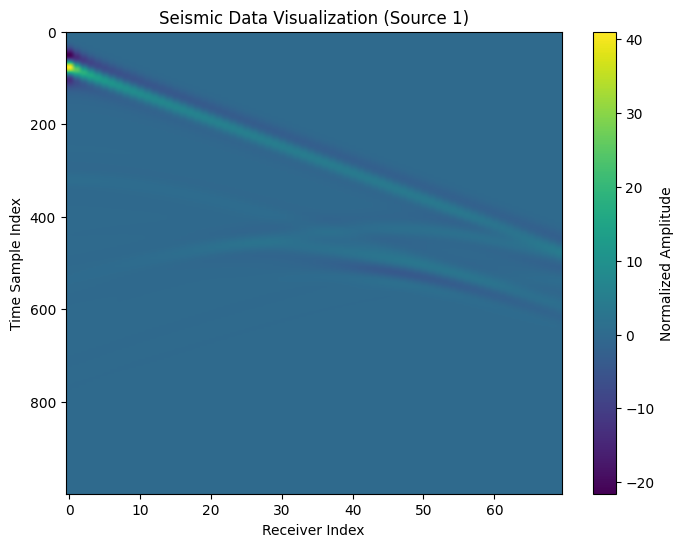

In [46]:
plt.figure(figsize=(8, 6))
plt.imshow(x_sample[0], aspect='auto', cmap='viridis')
plt.title("Seismic Data Visualization (Source 1)")
plt.xlabel("Receiver Index")
plt.ylabel("Time Sample Index")
plt.colorbar(label='Normalized Amplitude')
plt.savefig("Seismic Data Visualization.png", format="png")
plt.show()

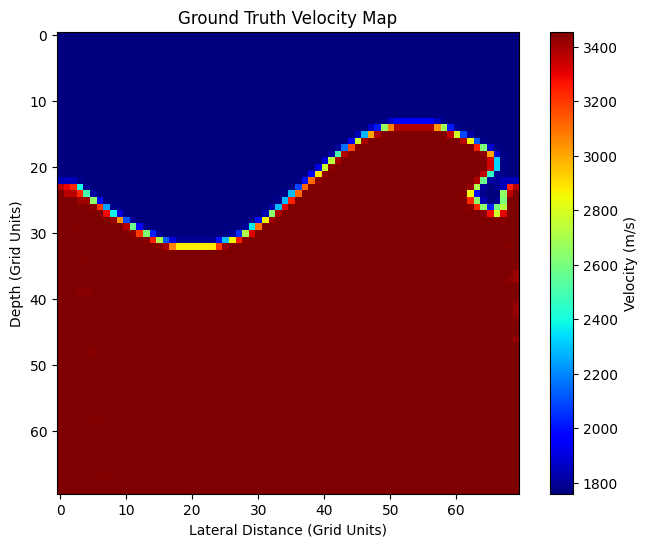

In [47]:
plt.figure(figsize=(8, 6))
plt.imshow(y_sample, cmap='jet')
plt.title("Ground Truth Velocity Map")
plt.xlabel("Lateral Distance (Grid Units)")
plt.ylabel("Depth (Grid Units)")
plt.colorbar(label='Velocity (m/s)')
plt.savefig("Ground Truth Velocity Map.png", format="png")
plt.show()

**Data Preprocessing**

In [48]:
print(x.mean(),x.std())
print(x.min(),x.max())
print(y.min(),y.max())

-0.00043087383 1.5608026
-26.058516 52.216263
1501.0 4500.0


In [49]:
xn = (x - x.mean()) / x.std()
yn = y / y.max()

In [50]:
X_train, y_train = torch.FloatTensor(xn), torch.FloatTensor(yn)

In [51]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, num_workers=1, batch_size=1, shuffle=True)

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


**Model Architecture**

(sources, time, receivers) : (5, 1000, 70)

time → height  
receivers → width  
sources → channels

*Perfect 2D grid → CNN-friendly*

In [53]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # --- ENCODER ---
        # Input : (B, 5, 1000, 70)
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels=5, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        ) # Output: 32x1000x70

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: 32x500x35

        self.enc2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        ) # Output: 64x500x35

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: 64x250x17 (Note: 35/2 = 17.5 -> 17)

        # --- BOTTLENECK ---
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        ) # Output: 128x250x17


        # --- DECODER ---
        # Note: output_padding=(0, 1) fixes the dimension mismatch caused by pooling 35 into 17
        self.up1 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2, output_padding=(0, 1))
        # Output: 64x500x35

        # After concat with enc2, input channels = 64 (up1) + 64 (enc2) = 128
        self.dec1 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        ) # Output: 64x500x35

        self.up2 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        # Output: 32x1000x70

        # After concat with enc1, input channels = 32 (up2) + 32 (enc1) = 64
        self.dec2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        ) # Output: 32x1000x70

        # --- FINAL OUTPUT ---
        self.final = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=1, stride=1, padding=0)
        # Output: 1x1000x70

    def forward(self, x):
        # x : (B, 5, 1000, 70)

        # Encoder pass
        x1 = self.enc1(x)         # -> (B, 32, 1000, 70)
        x2 = self.pool1(x1)       # -> (B, 32, 500, 35)

        x3 = self.enc2(x2)        # -> (B, 64, 500, 35)
        x4 = self.pool2(x3)       # -> (B, 64, 250, 17)

        # Bottleneck
        x5 = self.bottleneck(x4)  # -> (B, 128, 250, 17)

        # Decoder pass 1
        x6 = self.up1(x5)         # -> (B, 64, 500, 35)
        # Skip connection 1 (concatenate along channel dimension)
        cat1 = torch.cat([x3, x6], dim=1) # -> (B, 128, 500, 35)
        x7 = self.dec1(cat1)      # -> (B, 64, 500, 35)

        # Decoder pass 2
        x8 = self.up2(x7)         # -> (B, 32, 1000, 70)
        # Skip connection 2
        cat2 = torch.cat([x1, x8], dim=1) # -> (B, 64, 1000, 70)
        x9 = self.dec2(cat2)      # -> (B, 32, 1000, 70)

        # Output projection
        out = self.final(x9)      # -> (B, 1, 1000, 70)

        # Spatial adjustment to match ground truth target grids
        out = nn.functional.interpolate(input=out, size=(70, 70), mode='bilinear', align_corners=False)
        # -> (B, 1, 70, 70)

        return out.squeeze(1)     # -> (B, 70, 70)

In [54]:
uNet = UNet().to(device)

In [55]:
# For Sanity Check
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

pred = uNet(x)

print(pred.shape)

torch.Size([1, 70, 70])


**Total number of Parameters**

In [56]:
sum = 0
for param in uNet.parameters():
    sum += param.numel()
print(f"Total parameters: {sum}")

Total parameters: 467105


**Losses**

In [57]:
MSE = nn.MSELoss()

MAE = nn.L1Loss()

def gradient_loss(pred,target):
    dx_pred = pred[:, :, 1:] - pred[:, :, :-1]
    dx_true = target[:, :, 1:] - target[:, :, :-1]

    dy_pred = pred[:, 1:, :] - pred[:, :-1, :]
    dy_true = target[:, 1:, :] - target[:, :-1, :]

    return (dx_pred - dx_true).abs().mean() + (dy_pred - dy_true).abs().mean()


**Compilers**

In [58]:
optimizer = torch.optim.AdamW(uNet.parameters(), betas=(0.9, 0.999), lr=0.001)
n_epochs = 200
losses = []

**Training Loop**

In [59]:
for epoch in range(n_epochs):
    uNet.train()
    total_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        y_pred = uNet(x_batch)

        loss = 100 * (
            MAE(y_pred, y_batch)
            + 0.1 * MSE(y_pred, y_batch)
            + 0.5 * gradient_loss(y_pred, y_batch)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    mean_loss = total_loss / len(train_loader)
    losses.append(mean_loss)

    print(f"Epoch : {epoch+1}/{n_epochs}, Loss : {mean_loss}")

Epoch : 1/200, Loss : 17.569529795646666
Epoch : 2/200, Loss : 14.788932787895202
Epoch : 3/200, Loss : 13.692504310131072
Epoch : 4/200, Loss : 13.260495319366456
Epoch : 5/200, Loss : 12.573684978485108
Epoch : 6/200, Loss : 12.006007877349854
Epoch : 7/200, Loss : 11.663318649291993
Epoch : 8/200, Loss : 11.12574990606308
Epoch : 9/200, Loss : 10.454109889030457
Epoch : 10/200, Loss : 10.329596095085144
Epoch : 11/200, Loss : 9.914834384918214
Epoch : 12/200, Loss : 10.04464903640747
Epoch : 13/200, Loss : 9.564578551769257
Epoch : 14/200, Loss : 9.487950440406799
Epoch : 15/200, Loss : 9.573882225036622
Epoch : 16/200, Loss : 9.242207255840302
Epoch : 17/200, Loss : 9.044317562103272
Epoch : 18/200, Loss : 9.257686798572541
Epoch : 19/200, Loss : 9.034843185901641
Epoch : 20/200, Loss : 8.812898717880248
Epoch : 21/200, Loss : 8.716988881826401
Epoch : 22/200, Loss : 8.641020817756653
Epoch : 23/200, Loss : 8.597640662193298
Epoch : 24/200, Loss : 8.545665919780731
Epoch : 25/200, 

**Evaluation**

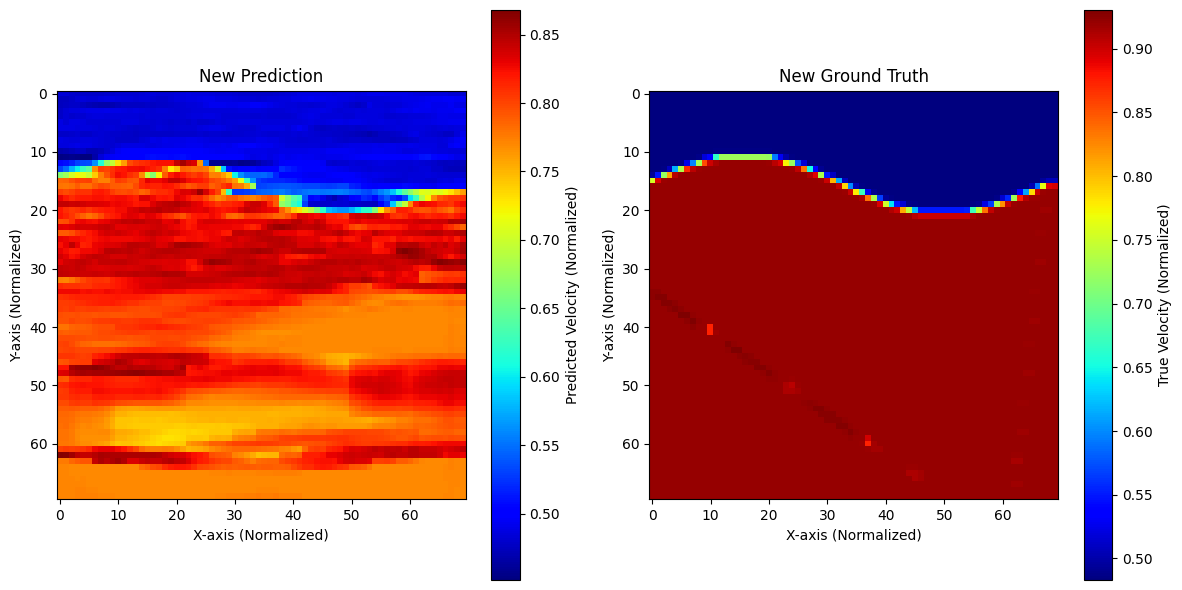

In [65]:
uNet.eval()
with torch.no_grad():

    x_new, y_new = next(iter(train_loader))
    x_new, y_new = x_new.to(device), y_new.to(device)

    y_pred_new = uNet(x_new)


    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("New Prediction")
    plt.imshow(y_pred_new[0].cpu().numpy(), cmap='jet')
    plt.colorbar(label='Predicted Velocity (Normalized)')
    plt.xlabel('X-axis (Normalized)')
    plt.ylabel('Y-axis (Normalized)')

    plt.subplot(1, 2, 2)
    plt.title("New Ground Truth")
    plt.imshow(y_new[0].cpu().numpy(), cmap='jet')
    plt.colorbar(label='True Velocity (Normalized)')
    plt.xlabel('X-axis (Normalized)')
    plt.ylabel('Y-axis (Normalized)')

    plt.tight_layout()
    plt.savefig("pred_vs_GT.png",format="png")
    plt.show()

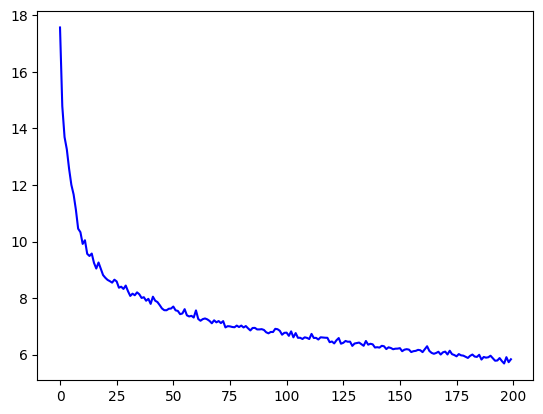

In [64]:
plt.plot(range(len(losses)),losses,color='blue')
plt.savefig("epochs_vs_loss.png",format="png")

**Model Save : v1**

In [ ]:
torch.save(uNet.state_dict(), "uNet_v1.pth")